# Fraud Detection for Vehicle Insurance Claims
## Эксперименты, тюнинг и финальная модель

In [1]:
# Импортируем библиотеки, подключаем корень проекта и функции из src.
from pathlib import Path
import sys

import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, fbeta_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Не удалось найти корень проекта (ожидались папки src и data).')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling import build_preprocessor, evaluate_model_dict, fit_and_score, get_scores_from_predictions
from src.preprocessing import prepare_datasets

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Загрузка processed-данных

In [2]:
# Загружаем processed-датасеты.
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Не удалось найти корень проекта (ожидались папки src и data).')


PROJECT_ROOT = find_project_root(Path.cwd())
processed_dir = PROJECT_ROOT / 'data' / 'processed'
clean_path = processed_dir / 'fraud_oracle_clean.csv'
fe_path = processed_dir / 'fraud_oracle_fe.csv'

if not clean_path.exists() or not fe_path.exists():
    prepare_datasets(save=True)

clean_df = pd.read_csv(clean_path)
fe_df = pd.read_csv(fe_path)

target_col = 'FraudFound_P'

## 2. Train / Validation / Test split

Разбиение выполняем до обучения моделей и со стратификацией по целевой переменной, чтобы сохранить долю fraud во всех выборках. Это помогает избежать data leakage. validation и test не участвуют в обучении модели, а все преобразования признаков выполняются внутри пайплайна, поэтому кодирование и масштабирование обучаются только на train-части и затем применяются к остальным данным без доступа к их статистикам.

In [3]:
# Готовим fe-выборку и делим данные на train/val/test со стратификацией.
X_fe = fe_df.drop(columns=[target_col])
y = fe_df[target_col]

X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train_fe, X_val_fe, y_train, y_val = train_test_split(
    X_train_fe, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

print('train:', X_train_fe.shape, y_train.shape)
print('val:', X_val_fe.shape, y_val.shape)
print('test:', X_test_fe.shape, y_test.shape)

train: (9251, 36) (9251,)
val: (3084, 36) (3084,)
test: (3084, 36) (3084,)


## 3. Препроцессинг и вспомогательные функции

In [4]:
# Собираем препроцессоры и объявляем вспомогательные функции для оценки моделей.
linear_preprocessor_fe, tree_preprocessor_fe, num_fe, cat_fe = build_preprocessor(X_train_fe)


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


def plot_pr_roc_curves(y_true, y_score, title_prefix='Model'):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision)
    plt.title(f'{title_prefix}: Precision-Recall curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f'{title_prefix}: ROC curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

## 4. Основные модели и ансамбли

In [5]:
# Определяем расширенный набор моделей и ансамблей для экспериментов.
advanced_models_fe = {
    "LogisticRegression": Pipeline([
        ("preprocessor", linear_preprocessor_fe),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "LinearSVC": Pipeline([
        ("preprocessor", linear_preprocessor_fe),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("preprocessor", linear_preprocessor_fe),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance", metric="manhattan")),
    ]),
    "DecisionTree": Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        )),
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", LGBMClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbose=-1,
        )),
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", tree_preprocessor_fe),
        ("model", CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="PRAUC",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=0,
        )),
    ]),
}

In [6]:
# Обучаем и оцениваем основные модели на fe-признаках.

advanced_fe_df, advanced_fe_fitted = evaluate_model_dict(
    advanced_models_fe,
    X_train_fe, y_train,
    X_val_fe, y_val,
    stage_name="advanced_fe",
    feature_set_name="fe",
)

display(advanced_fe_df.sort_values(by=["pr_auc", "recall", "f1"], ascending=False).style.format(precision=4))

,feature_set,stage,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
5,fe,advanced_fe,XGBoost,0.9413,0.5184,0.7000,0.0378,0.0718,0.8366,0.2479
6,fe,advanced_fe,LightGBM,0.8129,0.6905,0.1711,0.5514,0.2612,0.8357,0.2427
7,fe,advanced_fe,CatBoost,0.7896,0.7261,0.1714,0.6541,0.2716,0.8427,0.2147
4,fe,advanced_fe,RandomForest,0.6939,0.7486,0.1416,0.8108,0.2412,0.8186,0.1979
3,fe,advanced_fe,DecisionTree,0.6475,0.7366,0.1279,0.8378,0.2219,0.7739,0.1680
0,fe,advanced_fe,LogisticRegression,0.6741,0.7583,0.1391,0.8541,0.2392,0.8041,0.1624
1,fe,advanced_fe,LinearSVC,0.6595,0.7531,0.1344,0.8595,0.2325,0.7966,0.1619
2,fe,advanced_fe,KNN,0.9329,0.5089,0.1562,0.0270,0.0461,0.6013,0.0937


Среди основных моделей и ансамблей лучший PR-AUC показал XGBoost (0.2479), а близкие результаты также дали LightGBM (0.2427) и CatBoost (0.2147). Это означает, что ансамбли лучше ранжируют fraud-случаи, чем более простые baseline-модели.

При этом XGBoost на стандартном пороге оказался слишком консервативным: несмотря на высокий PR-AUC, его recall всего 0.0378. Более практичными по балансу между поиском fraud и качеством ранжирования выглядят LightGBM и CatBoost, так как они сохраняют хороший PR-AUC и одновременно дают заметно более высокий recall.

RandomForest, DecisionTree, LogisticRegression и LinearSVC лучше ловят fraud по recall, но уступают градиентным ансамблям по PR-AUC. KNN снова показывает слабый результат и остаётся одной из наименее полезных моделей в этом наборе.

## 5. Подбор гиперпараметров

Сделаем подбор гипперпараметров сильных моделей:
- Logistic Regression
- Random Forest
- LightGBM

Метрикой подбора берем PR-AUC, так как у нас редкий положительный класс. Threshold будет позже подстроен под Recall и f1.

In [7]:
# Задаём кросс-валидацию и сетки гиперпараметров для tuned-моделей.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_models = {
    "LogisticRegression": {
        "pipeline": Pipeline([
            ("preprocessor", linear_preprocessor_fe),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        "param_grid": {
            "model__C": [0.1, 0.3, 1.0, 3.0],
            "model__class_weight": [None, "balanced"],
            "model__solver": ["liblinear", "lbfgs"],
        },
    },
    "RandomForest": {
        "pipeline": Pipeline([
            ("preprocessor", tree_preprocessor_fe),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [6, 10, None],
            "model__min_samples_leaf": [1, 5, 10],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        },
    },
    "LightGBM": {
        "pipeline": Pipeline([
            ("preprocessor", tree_preprocessor_fe),
            ("model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [4, 6, -1],
            "model__class_weight": [None, "balanced"],
        },
    },
    "CatBoost": {
        "pipeline": Pipeline([
            ("preprocessor", tree_preprocessor_fe),
            ("model", CatBoostClassifier(
                loss_function="Logloss",
                eval_metric="PRAUC",
                random_seed=RANDOM_STATE,
                verbose=0,
            )),
        ]),
        "param_grid": {
            "model__iterations": [200, 400],
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__l2_leaf_reg": [3, 5, 7],
            "model__auto_class_weights": ["Balanced", None],
        },
    },
}

In [8]:
# Запускаем GridSearchCV, сохраняем лучшие модели и собираем tuned-результаты.
tuned_rows = []
best_estimators = {}

for model_name, config in tuned_models.items():
    print(f"GridSearchCV для {model_name}...")

    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    search.fit(X_train_fe, y_train)
    best_model = search.best_estimator_
    best_estimators[model_name] = best_model

    y_val_pred = best_model.predict(X_val_fe)

    if hasattr(best_model, "predict_proba"):
        y_val_score = best_model.predict_proba(X_val_fe)[:, 1]
    elif hasattr(best_model, "decision_function"):
        y_val_score = best_model.decision_function(X_val_fe)
    else:
        y_val_score = None

    row = {
        "feature_set": "fe",
        "stage": "tuned",
        "model": model_name,
        "best_params": search.best_params_,
        "cv_best_ap": search.best_score_,
    }
    row.update(get_scores_from_predictions(y_val, y_val_pred, y_val_score))
    tuned_rows.append(row)

tuned_df = pd.DataFrame(tuned_rows).sort_values(by=["pr_auc", "recall", "f1"], ascending=False)
display(tuned_df)

GridSearchCV для LogisticRegression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV для RandomForest...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
GridSearchCV для LightGBM...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearchCV для CatBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


,feature_set,stage,model,best_params,cv_best_ap,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
2,fe,tuned,LightGBM,"{'model__class_weight': None, 'model__learning...",0.264628,0.941958,0.516216,1.000000,0.032432,0.062827,0.838453,0.248569
3,fe,tuned,CatBoost,"{'model__auto_class_weights': 'Balanced', 'mod...",0.252437,0.803826,0.728659,0.180851,0.643243,0.282325,0.849012,0.246611
1,fe,tuned,RandomForest,"{'model__class_weight': None, 'model__max_dept...",0.253869,0.940013,0.500000,0.000000,0.000000,0.000000,0.822485,0.245355
0,fe,tuned,LogisticRegression,"{'model__C': 0.1, 'model__class_weight': None,...",0.164399,0.939364,0.499655,0.000000,0.000000,0.000000,0.808199,0.171504


После GridSearchCV лучший результат по PR-AUC на validation показал LightGBM (0.2486), совсем рядом находится CatBoost (0.2466). При этом по практическим бинарным метрикам модели ведут себя по-разному: LightGBM имеет очень высокую precision, но почти не находит fraud при стандартном пороге (recall = 0.0324, F1 = 0.0628). CatBoost выглядит более сбалансированным вариантом: его PR-AUC почти такой же, но recall = 0.6432, F1 = 0.2823, а balanced_accuracy = 0.7287.  

## 6. Таблица всех экспериментов

Сводим вместе расширенный набор моделей и tuned-результаты

In [9]:
# Объединяем результаты основных и tuned-экспериментов в общую таблицу.
all_experiments_df = pd.concat(
    [
        advanced_fe_df,
        tuned_df.drop(columns=['best_params', 'cv_best_ap'], errors='ignore'),
    ],
    ignore_index=True,
).sort_values(by=['pr_auc', 'recall', 'f1'], ascending=False)

display(all_experiments_df.style.format(precision=4))

,feature_set,stage,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
8,fe,tuned,LightGBM,0.9420,0.5162,1.0000,0.0324,0.0628,0.8385,0.2486
5,fe,advanced_fe,XGBoost,0.9413,0.5184,0.7000,0.0378,0.0718,0.8366,0.2479
9,fe,tuned,CatBoost,0.8038,0.7287,0.1809,0.6432,0.2823,0.8490,0.2466
10,fe,tuned,RandomForest,0.9400,0.5000,0.0000,0.0000,0.0000,0.8225,0.2454
6,fe,advanced_fe,LightGBM,0.8129,0.6905,0.1711,0.5514,0.2612,0.8357,0.2427
7,fe,advanced_fe,CatBoost,0.7896,0.7261,0.1714,0.6541,0.2716,0.8427,0.2147
4,fe,advanced_fe,RandomForest,0.6939,0.7486,0.1416,0.8108,0.2412,0.8186,0.1979
11,fe,tuned,LogisticRegression,0.9394,0.4997,0.0000,0.0000,0.0000,0.8082,0.1715
3,fe,advanced_fe,DecisionTree,0.6475,0.7366,0.1279,0.8378,0.2219,0.7739,0.1680
0,fe,advanced_fe,LogisticRegression,0.6741,0.7583,0.1391,0.8541,0.2392,0.8041,0.1624



В общей таблице лучше всего по PR-AUC выглядят tuned LightGBM (0.2486), advanced XGBoost (0.2479), tuned CatBoost (0.2466) и tuned RandomForest (0.2454). Разница между лидерами небольшая, поэтому выбирать финальную модель только по PR-AUC рискованно. Часть моделей хорошо ранжирует объекты, но почти не относит заявки к классу fraud при стандартном пороге.  

Если смотреть на практические метрики, самым сбалансированным кандидатом выглядит tuned CatBoost: он сохраняет высокий PR-AUC и одновременно дает заметный recall (0.6432) и лучший F1 среди верхних моделей (0.2823). Advanced LightGBM тоже выглядит рабочим вариантом, но уступает CatBoost по recall и F1. RandomForest хорошо ловит fraud по recall в advanced-режиме, но делает это слишком агрессивно и проигрывает лидерам по PR-AUC.  

## 7. Уменьшение размерности

Так как после one-hot encoding количество признаков растёт, делаем эксперимент с TruncatedSVD.

In [10]:
# Преобразуем данные после preprocessing и оцениваем размерность пространства признаков.

X_train_fe_transformed = linear_preprocessor_fe.fit_transform(X_train_fe)
X_val_fe_transformed = linear_preprocessor_fe.transform(X_val_fe)

print("Размер пространства после preprocessing:")
print("Train:", X_train_fe_transformed.shape)
print("Validation:", X_val_fe_transformed.shape)

Размер пространства после preprocessing:
Train: (9251, 196)
Validation: (3084, 196)


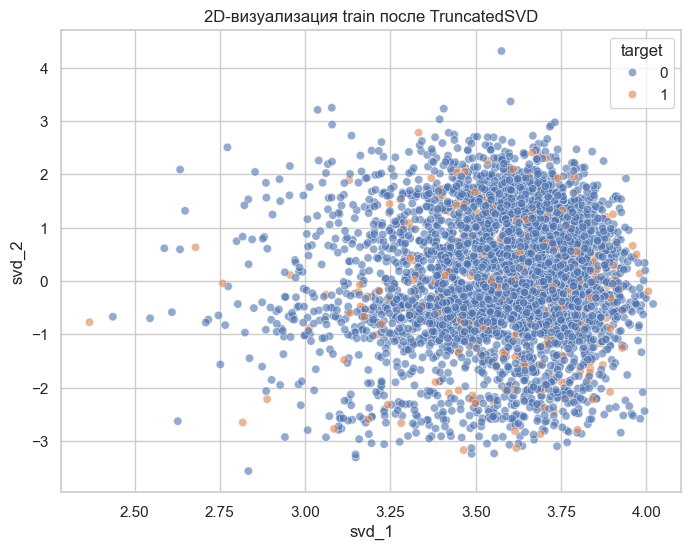

Explained variance ratio (2 components): 0.0669


In [11]:
# Строим 2D-проекцию через TruncatedSVD для визуального анализа структуры данных.

svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_train_fe_2d = svd_2d.fit_transform(X_train_fe_transformed)

svd_vis_df = pd.DataFrame({
    "svd_1": X_train_fe_2d[:, 0],
    "svd_2": X_train_fe_2d[:, 1],
    "target": y_train.reset_index(drop=True),
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=svd_vis_df.sample(min(4000, len(svd_vis_df)), random_state=RANDOM_STATE),
    x="svd_1",
    y="svd_2",
    hue="target",
    alpha=0.6,
)
plt.title("2D-визуализация train после TruncatedSVD")
plt.show()

print("Explained variance ratio (2 components):", round(svd_2d.explained_variance_ratio_.sum(), 4))

In [ ]:
# Проверяем модели на разных размерностях после TruncatedSVD и собираем результаты.

svd_rows = []

for n_components in [10, 20, 30, 50]:
    for model_name, estimator in [
        ("LogisticRegression", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
        ("LightGBM", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            verbose=-1,
        )),
    ]:
        svd_pipeline = Pipeline([
            ("preprocessor", linear_preprocessor_fe),
            ("svd", TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
            ("model", estimator),
        ])

        fitted_model, scores = fit_and_score(svd_pipeline, X_train_fe, y_train, X_val_fe, y_val)
        row = {
            "feature_set": "fe",
            "stage": f"svd_{n_components}",
            "model": model_name,
            "n_components": n_components,
        }
        row.update(scores)
        svd_rows.append(row)

svd_df = pd.DataFrame(svd_rows).sort_values(by=["pr_auc", "recall", "f1"], ascending=False)
display(svd_df.style.format(precision=4))

,feature_set,stage,model,n_components,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
5,fe,svd_30,LightGBM,30,0.8577,0.6282,0.1744,0.3676,0.2365,0.7903,0.1946
7,fe,svd_50,LightGBM,50,0.8687,0.5962,0.1626,0.2865,0.2074,0.7919,0.1613
6,fe,svd_50,LogisticRegression,50,0.6349,0.7451,0.1275,0.8703,0.2224,0.7906,0.1584
3,fe,svd_20,LightGBM,20,0.8262,0.6343,0.1525,0.4162,0.2232,0.7834,0.1550
4,fe,svd_30,LogisticRegression,30,0.6196,0.7370,0.1229,0.8703,0.2154,0.7889,0.1522
2,fe,svd_20,LogisticRegression,20,0.6297,0.7246,0.1217,0.8324,0.2124,0.7832,0.1467
1,fe,svd_10,LightGBM,10,0.8022,0.6063,0.1252,0.3838,0.1888,0.7224,0.1254
0,fe,svd_10,LogisticRegression,10,0.4692,0.5886,0.0779,0.7243,0.1407,0.6151,0.0726


После preprocessing пространство признаков выросло до 196 колонок, поэтому TruncatedSVD проверяется как способ сжать one-hot признаки и посмотреть, сохраняется ли качество моделей. На 2D-графике классы сильно перемешаны, а две компоненты объясняют только 0.0669 дисперсии. Это означает, что в двух измерениях явного разделения fraud и non-fraud не видно, и такая проекция подходит скорее для визуальной проверки, чем для полноценного обучения.  

В таблице лучший результат среди SVD-экспериментов дает LightGBM с 30 компонентами: PR-AUC = 0.1946, recall = 0.3676, F1 = 0.2365. Это лучше, чем варианты с 10 и 20 компонентами, но заметно хуже лидеров без SVD, где PR-AUC был около 0.246-0.249. LogisticRegression после SVD хорошо поднимает recall, особенно при 30 и 50 компонентах, но precision остается низкой, поэтому модель слишком часто относит обычные заявки к fraud.  

## 8. Выбор финальной модели

Раньше финальная модель выбиралась только по PR-AUC, из-за чего можно было получить модель,
которая хорошо ранжирует объекты, но почти не предсказывает fraud при стандартном пороге 0.5.

Поэтому теперь делаем более практичный отбор:

1. Сначала смотрим сильные кандидаты по PR-AUC.
2. Затем для каждого кандидата подбираем threshold на validation.
3. Финальную модель выбираем уже по качеству после настройки порога, чтобы она реально находила fraud.


In [ ]:
# Объединяем все эксперименты и выбираем кандидатов для дальнейшего отбора.
selection_df = pd.concat(
    [all_experiments_df, svd_df.drop(columns=["n_components"], errors="ignore")],
    ignore_index=True,
).sort_values(by=["pr_auc", "recall", "f1"], ascending=False).reset_index(drop=True)

display(selection_df.style.format(precision=4))

display(Markdown(
    "### Кандидаты для финального отбора\n"
    "Берём модели с хорошим `PR-AUC` и не нулевым `recall`, "
    "а затем подберём для них лучший threshold на validation."
))

candidate_df = (
    selection_df[selection_df["roc_auc"].notna()]
    .sort_values(by=["pr_auc", "recall", "f1"], ascending=False)
    .head(12)
    .reset_index(drop=True)
)

display(candidate_df.style.format(precision=4))

,feature_set,stage,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,fe,tuned,LightGBM,0.9420,0.5162,1.0000,0.0324,0.0628,0.8385,0.2486
1,fe,advanced_fe,XGBoost,0.9413,0.5184,0.7000,0.0378,0.0718,0.8366,0.2479
2,fe,tuned,CatBoost,0.8038,0.7287,0.1809,0.6432,0.2823,0.8490,0.2466
3,fe,tuned,RandomForest,0.9400,0.5000,0.0000,0.0000,0.0000,0.8225,0.2454
4,fe,advanced_fe,LightGBM,0.8129,0.6905,0.1711,0.5514,0.2612,0.8357,0.2427
5,fe,advanced_fe,CatBoost,0.7896,0.7261,0.1714,0.6541,0.2716,0.8427,0.2147
6,fe,advanced_fe,RandomForest,0.6939,0.7486,0.1416,0.8108,0.2412,0.8186,0.1979
7,fe,svd_30,LightGBM,0.8577,0.6282,0.1744,0.3676,0.2365,0.7903,0.1946
8,fe,tuned,LogisticRegression,0.9394,0.4997,0.0000,0.0000,0.0000,0.8082,0.1715
9,fe,advanced_fe,DecisionTree,0.6475,0.7366,0.1279,0.8378,0.2219,0.7739,0.1680


### Кандидаты для финального отбора
Берём модели с хорошим `PR-AUC` и не нулевым `recall`, а затем подберём для них лучший threshold на validation.

,feature_set,stage,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,fe,tuned,LightGBM,0.9420,0.5162,1.0000,0.0324,0.0628,0.8385,0.2486
1,fe,advanced_fe,XGBoost,0.9413,0.5184,0.7000,0.0378,0.0718,0.8366,0.2479
2,fe,tuned,CatBoost,0.8038,0.7287,0.1809,0.6432,0.2823,0.8490,0.2466
3,fe,tuned,RandomForest,0.9400,0.5000,0.0000,0.0000,0.0000,0.8225,0.2454
4,fe,advanced_fe,LightGBM,0.8129,0.6905,0.1711,0.5514,0.2612,0.8357,0.2427
5,fe,advanced_fe,CatBoost,0.7896,0.7261,0.1714,0.6541,0.2716,0.8427,0.2147
6,fe,advanced_fe,RandomForest,0.6939,0.7486,0.1416,0.8108,0.2412,0.8186,0.1979
7,fe,svd_30,LightGBM,0.8577,0.6282,0.1744,0.3676,0.2365,0.7903,0.1946
8,fe,tuned,LogisticRegression,0.9394,0.4997,0.0000,0.0000,0.0000,0.8082,0.1715
9,fe,advanced_fe,DecisionTree,0.6475,0.7366,0.1279,0.8378,0.2219,0.7739,0.1680



В общий список вошли модели из advanced-экспериментов, tuned-модели и варианты после SVD. По PR-AUC сверху остаются tuned LightGBM (0.2486), advanced XGBoost (0.2479), tuned CatBoost (0.2466) и tuned RandomForest (0.2454). Но первые две модели при стандартном пороге почти не находят fraud: recall у LightGBM равен 0.0324, у XGBoost - 0.0378.  

Поэтому для финального отбора важно смотреть не только на ранжирование, но и на поведение модели после выбора порога. В этом смысле tuned CatBoost выглядит самым сильным кандидатом уже до threshold tuning. PR-AUC почти как у лидеров, но recall = 0.6432 и F1 = 0.2823. SVD-варианты в список попадают ниже, потому что после сжатия признаков качество по PR-AUC заметно падает.

## 9. Подбор threshold на validation

Теперь делаем более сбалансированный выбор threshold на validation. Сначала проверяем разные значения порога, затем сравниваем precision, recall и F1 и выбираем вариант с наиболее разумным балансом для финальной проверки на test.


In [ ]:
# Восстанавливаем pipeline и нужные данные для выбранного кандидата перед threshold tuning.
def rebuild_candidate_model(row):
    model = row['model']
    stage = row['stage']

    X_train_part = X_train_fe
    X_val_part = X_val_fe
    X_test_part = X_test_fe

    if stage == 'advanced_fe':
        pipeline = clone(advanced_models_fe[model])
    elif stage == 'tuned':
        pipeline = clone(best_estimators[model])
    elif isinstance(stage, str) and stage.startswith('svd_'):
        n_components = int(stage.split('_')[1])

        if model == 'LogisticRegression':
            estimator = LogisticRegression(
                max_iter=3000,
                class_weight='balanced',
                random_state=RANDOM_STATE,
            )
        else:
            estimator = LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=6,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                verbose=-1,
            )

        pipeline = Pipeline([
            ('preprocessor', linear_preprocessor_fe),
            ('svd', TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)),
            ('model', estimator),
        ])
    else:
        raise ValueError(f'Unknown stage: {stage}')

    return pipeline, X_train_part, X_val_part, X_test_part


def get_scores_for_threshold(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    scores = get_scores_from_predictions(y_true, y_pred, y_score)
    scores['f2'] = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    scores['threshold'] = threshold
    return scores


threshold_rows = []

for _, row in candidate_df.iterrows():
    model_pipeline, X_train_part, X_val_part, X_test_part = rebuild_candidate_model(row)

    model_pipeline.fit(X_train_part, y_train)

    if hasattr(model_pipeline, 'predict_proba'):
        y_val_score = model_pipeline.predict_proba(X_val_part)[:, 1]
    elif hasattr(model_pipeline, 'decision_function'):
        raw_score = model_pipeline.decision_function(X_val_part)
        y_val_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-9)
    else:
        continue

    local_rows = []
    for threshold in np.arange(0.03, 0.46, 0.01):
        scores = get_scores_for_threshold(y_val, y_val_score, threshold)
        local_rows.append(scores)

    local_df = pd.DataFrame(local_rows)

    balanced_local_df = local_df[
        (local_df['recall'] >= 0.75) &
        (local_df['precision'] >= 0.15)
    ].copy()

    if not balanced_local_df.empty:
        best_threshold_row = balanced_local_df.sort_values(
            by=['f1', 'precision', 'pr_auc', 'recall'],
            ascending=False,
        ).iloc[0]
    else:
        fallback_df = local_df[local_df['recall'] >= 0.70].copy()
        if fallback_df.empty:
            best_threshold_row = local_df.sort_values(
                by=['f1', 'precision', 'pr_auc', 'recall'],
                ascending=False,
            ).iloc[0]
        else:
            best_threshold_row = fallback_df.sort_values(
                by=['f1', 'precision', 'pr_auc', 'recall'],
                ascending=False,
            ).iloc[0]

    threshold_rows.append({
        'feature_set': row['feature_set'],
        'stage': row['stage'],
        'model': row['model'],
        'val_accuracy': best_threshold_row['accuracy'],
        'val_balanced_accuracy': best_threshold_row['balanced_accuracy'],
        'val_precision': best_threshold_row['precision'],
        'val_recall': best_threshold_row['recall'],
        'val_f1': best_threshold_row['f1'],
        'val_f2': best_threshold_row['f2'],
        'val_roc_auc': best_threshold_row['roc_auc'],
        'val_pr_auc': best_threshold_row['pr_auc'],
        'best_threshold': best_threshold_row['threshold'],
    })

threshold_tuned_df = pd.DataFrame(threshold_rows).sort_values(
    by=['val_f1', 'val_precision', 'val_recall', 'val_pr_auc'],
    ascending=False,
).reset_index(drop=True)

display(threshold_tuned_df.style.format(precision=4))

best_threshold_row = threshold_tuned_df.iloc[0]

display(Markdown(
    (
        '### Финальная конфигурация после настройки threshold\n'
        f"- **Feature set:** {best_threshold_row['feature_set']}\n"
        f"- **Stage:** {best_threshold_row['stage']}\n"
        f"- **Model:** {best_threshold_row['model']}\n"
        f"- **Best threshold:** {best_threshold_row['best_threshold']:.2f}\n"
        f"- **Validation recall:** {best_threshold_row['val_recall']:.4f}\n"
        f"- **Validation precision:** {best_threshold_row['val_precision']:.4f}\n"
        f"- **Validation F1:** {best_threshold_row['val_f1']:.4f}\n"
        f"- **Validation PR-AUC:** {best_threshold_row['val_pr_auc']:.4f}"
    )
))

,feature_set,stage,model,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,val_f2,val_roc_auc,val_pr_auc,best_threshold
0,fe,tuned,CatBoost,0.7260,0.7885,0.1626,0.8595,0.2734,0.4627,0.8490,0.2466,0.3300
1,fe,advanced_fe,CatBoost,0.7497,0.7505,0.1607,0.7514,0.2648,0.4330,0.8427,0.2147,0.4200
2,fe,tuned,LightGBM,0.7370,0.7614,0.1590,0.7892,0.2647,0.4403,0.8385,0.2486,0.0900
3,fe,advanced_fe,LightGBM,0.7455,0.7482,0.1583,0.7514,0.2615,0.4295,0.8357,0.2427,0.3600
4,fe,tuned,RandomForest,0.7364,0.7484,0.1549,0.7622,0.2575,0.4273,0.8225,0.2454,0.0900
5,fe,advanced_fe,XGBoost,0.7309,0.7480,0.1529,0.7676,0.2549,0.4254,0.8366,0.2479,0.0700
6,fe,tuned,LogisticRegression,0.7419,0.7311,0.1517,0.7189,0.2505,0.4113,0.8082,0.1715,0.0900
7,fe,advanced_fe,RandomForest,0.6566,0.7642,0.1364,0.8865,0.2365,0.4222,0.8186,0.1979,0.4600
8,fe,advanced_fe,LogisticRegression,0.6391,0.7701,0.1341,0.9189,0.2340,0.4233,0.8041,0.1624,0.4000
9,fe,svd_30,LightGBM,0.6991,0.7210,0.1354,0.7459,0.2292,0.3923,0.7903,0.1946,0.2400


### Финальная конфигурация после настройки threshold
- **Feature set:** fe
- **Stage:** tuned
- **Model:** CatBoost
- **Best threshold:** 0.33
- **Validation recall:** 0.8595
- **Validation precision:** 0.1626
- **Validation F1:** 0.2734
- **Validation PR-AUC:** 0.2466


После перебора порогов лучшей конфигурацией стал tuned CatBoost с threshold = 0.33. На validation он дает recall = 0.8595, precision = 0.1626, F1 = 0.2734 и PR-AUC = 0.2466. Это хороший компромисс для fraud detection: модель находит большую часть мошеннических случаев, но precision остается не нулевой и лучше, чем у слишком агрессивных вариантов.  

LightGBM после настройки threshold тоже стал гораздо полезнее, чем при стандартном predict: recall поднялся до 0.7892 при threshold = 0.09. Но по F1 он чуть уступает CatBoost. Advanced CatBoost близок к лидеру, однако tuned CatBoost сохраняет более высокий recall и лучший итоговый F1. Поэтому финально выбираем tuned CatBoost, а threshold фиксируем на validation, чтобы test остался честной финальной проверкой.

## 10. Финальное обучение на train + validation и проверка на test

Финальную модель дообучаем на train + validation, а затем применяем подобранный threshold.


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,model,stage,feature_set,best_threshold
0,0.7101,0.8129,0.1633,0.9297,0.2779,0.8680,0.2647,CatBoost,tuned,fe,0.3300



Confusion matrix counts:
TN = 2018
FP = 881
FN = 13
TP = 172

Человеческая интерпретация:
Правильно распознано честных заявок: 2018
Ложно обвинено честных заявок: 881
Пропущено fraud-случаев: 13
Правильно найдено fraud-случаев: 172

Classification report on test:
              precision    recall  f1-score   support

           0     0.9936    0.6961    0.8187      2899
           1     0.1633    0.9297    0.2779       185

    accuracy                         0.7101      3084
   macro avg     0.5785    0.8129    0.5483      3084
weighted avg     0.9438    0.7101    0.7862      3084



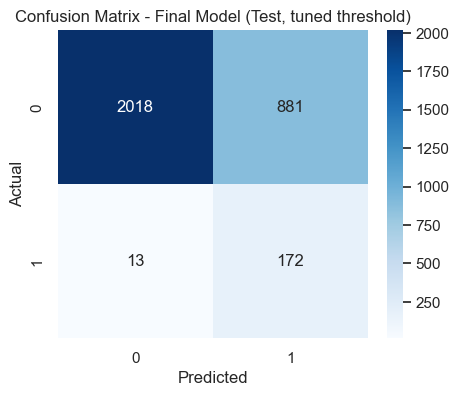

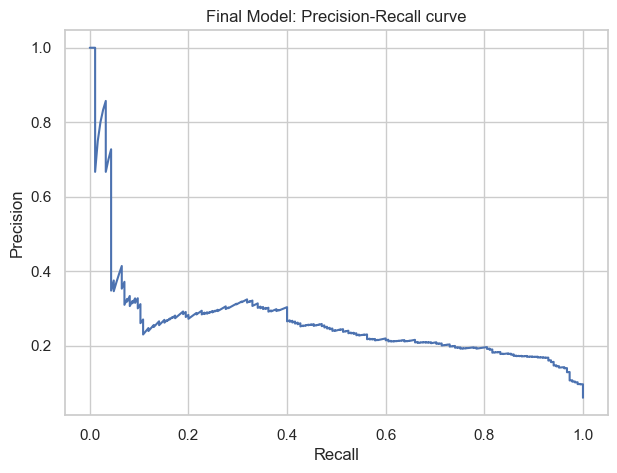

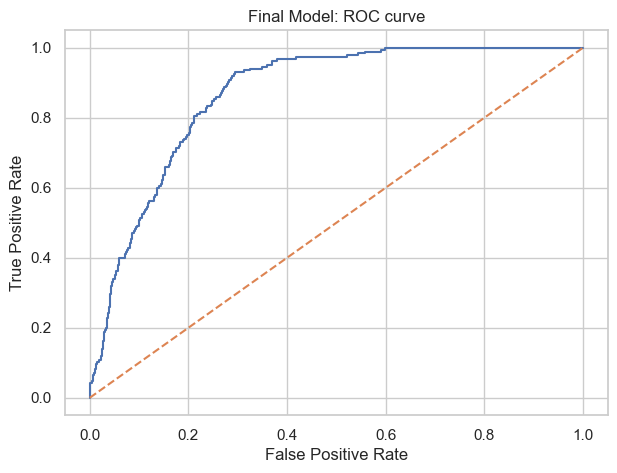

In [15]:
# Дообучаем финальную модель, применяем лучший threshold и оцениваем качество на test.
final_row_for_rebuild = selection_df[
    (selection_df["feature_set"] == best_threshold_row["feature_set"]) &
    (selection_df["stage"] == best_threshold_row["stage"]) &
    (selection_df["model"] == best_threshold_row["model"])
].iloc[0]

final_model, X_train_part, X_val_part, X_test_part = rebuild_candidate_model(final_row_for_rebuild)

X_train_val_final = pd.concat([X_train_part, X_val_part], axis=0)
y_train_val_final = pd.concat([y_train, y_val], axis=0)

final_model.fit(X_train_val_final, y_train_val_final)

if hasattr(final_model, "predict_proba"):
    y_test_score = final_model.predict_proba(X_test_part)[:, 1]
elif hasattr(final_model, "decision_function"):
    raw_score = final_model.decision_function(X_test_part)
    y_test_score = (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min() + 1e-9)
else:
    y_test_score = None

if y_test_score is not None:
    final_threshold = float(best_threshold_row["best_threshold"])
    y_test_pred = (y_test_score >= final_threshold).astype(int)
else:
    final_threshold = np.nan
    y_test_pred = final_model.predict(X_test_part)

final_test_scores = pd.DataFrame([get_scores_from_predictions(y_test, y_test_pred, y_test_score)])
final_test_scores["model"] = best_threshold_row["model"]
final_test_scores["stage"] = best_threshold_row["stage"]
final_test_scores["feature_set"] = best_threshold_row["feature_set"]
final_test_scores["best_threshold"] = final_threshold

display(final_test_scores.style.format(precision=4))

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
print("\nConfusion matrix counts:")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nЧеловеческая интерпретация:")
print(f"Правильно распознано честных заявок: {tn}")
print(f"Ложно обвинено честных заявок: {fp}")
print(f"Пропущено fraud-случаев: {fn}")
print(f"Правильно найдено fraud-случаев: {tp}")

print("\nClassification report on test:")
print(classification_report(y_test, y_test_pred, digits=4))

plot_confusion(y_test, y_test_pred, "Confusion Matrix - Final Model (Test, tuned threshold)")

if y_test_score is not None:
    plot_pr_roc_curves(y_test, y_test_score, title_prefix="Final Model")

Финальная модель - tuned CatBoost с threshold = 0.33, дообученный на train + validation. На test модель получила PR-AUC = 0.2647, ROC-AUC = 0.8680, recall = 0.9297 и F1 = 0.2779. По confusion matrix она правильно нашла 172 fraud-случая из 185 и пропустила только 13.  

Главным минусом остается большое число ложных срабатываний. 881 честная заявка попала в fraud. В данном случае я поставил приоритет на обнарежение мошенников. Если бизнесу важнее снизить число ложных обвинений, threshold нужно поднять и заново оценить баланс между precision и recall.

## 11. Выводы и обоснование финальной модели

В проекте были проверены несколько групп моделей. Простые baseline-подходы, ансамбли, tuned-модели после GridSearchCV и варианты с уменьшением размерности через TruncatedSVD. Лучшие значения PR-AUC дали градиентные ансамбли, особенно LightGBM, XGBoost и CatBoost. При этом модели с максимальным PR-AUC не всегда были лучшими на практике. При стандартном пороге они могли почти не предсказывать fraud-класс.  

Финальная модель выбрана не только по PR-AUC, но и по качеству после настройки threshold на validation. Лучшим компромиссом стал tuned CatBoost с threshold = 0.33. Он сохраняет хорошее качество ранжирования и при этом реально находит большинство fraud-случаев. На test модель показала recall = 0.9297 и PR-AUC = 0.2647, то есть хорошо выполняет главную цель задачи - не пропускать мошеннические заявки.  

Ограничение финального решения - низкая precision и большое количество false positive. Это не ошибка модели, а следствие выбранного приоритета. Высокий recall достигается ценой большего числа ложных подозрений. В реальном применении threshold можно настраивать под бизнес-стоимость ошибок. ниже порог - больше найденного fraud, выше порог - меньше ложных обвинений.